<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> DGM </b><br><br>HW1_Q2</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>


Q2-part1-subdivision4

In [2]:
# Install necessary libraries
# !pip install torch torchvision matplotlib numpy tensorflow_datasets

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import save_image
import torch.optim.lr_scheduler as lr_scheduler
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from torchvision.utils import make_grid

# For downloading the dataset
import tensorflow_datasets as tfds

# Mount Google Drive (optional, for saving models and outputs)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_MOUNTED = True
    print("Google Drive mounted successfully.")
except ImportError:
    DRIVE_MOUNTED = False
    print("Not running in Google Colab. Google Drive not mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


In [4]:
# --- Original Hyperparameters ---
INITIAL_LR = 0.001
IMG_DIM = (64, 64)

# --- New/Adjusted Hyperparameters ---
# Increased epochs to allow for early stopping
MAX_EPOCHS = 100
BATCH_SIZE = 128
# Latent dimension (h_dim from your table)
H_DIM = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Scheduler and Early Stopping Parameters ---
# ReduceLROnPlateau: Wait 8 epochs for loss to improve, then reduce LR by factor of 0.5 (halve it)
SCHEDULER_PATIENCE = 8
SCHEDULER_FACTOR = 0.5
# EarlyStopping: Wait 15 epochs for loss to improve, then stop training
EARLY_STOP_PATIENCE = 15

# Paths for saving outputs (uses Google Drive if available)
BASE_PATH = "/content/drive/My Drive/VAE_dsprites/" if DRIVE_MOUNTED else "./"
if not os.path.exists(BASE_PATH):
    os.makedirs(BASE_PATH)

BEST_MODEL_SAVE_PATH = os.path.join(BASE_PATH, "vae_dsprites_best_model.pth")
RECON_IMAGE_PATH = os.path.join(BASE_PATH, "vae_recon_epoch_{}.png")

print(f"Training on device: {DEVICE}")
print(f"Max Epochs: {MAX_EPOCHS}")
print(f"Latent dimension (h_dim): {H_DIM}")
print(f"Scheduler Patience: {SCHEDULER_PATIENCE}, Factor: {SCHEDULER_FACTOR}")
print(f"Early Stopping Patience: {EARLY_STOP_PATIENCE}")
print(f"Model will be saved to: {BEST_MODEL_SAVE_PATH}")


# # Create DataLoader
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2, # Recommended for Colab
    pin_memory=True # Speeds up CPU-to-GPU data transfer
)

Training on device: cuda
Max Epochs: 100
Latent dimension (h_dim): 10
Scheduler Patience: 8, Factor: 0.5
Early Stopping Patience: 15
Model will be saved to: /content/drive/My Drive/VAE_dsprites/vae_dsprites_best_model.pth


In [ ]:
print("Loading dsprites dataset (FINAL Robust Method - TFDS + uint8)...")

# Define the *target* file path. I'm using a new name to avoid conflicts.
PROCESSED_FILENAME = 'dsprites_FINAL_uint8_N-C-H-W.npy'
PROCESSED_PATH = os.path.join(BASE_PATH, PROCESSED_FILENAME)

all_images_np_uint8 = None

# 1. Try to load the final, processed uint8 file (FAST PATH)
if os.path.exists(PROCESSED_PATH):
    print(f"Loading pre-processed uint8 data from: {PROCESSED_PATH}")
    all_images_np_uint8 = np.load(PROCESSED_PATH)

# 2. If it doesn't exist, create it using TFDS (ONE-TIME SLOW PATH - NO CRASH)
else:
    print(f"Pre-processed file not found at: {PROCESSED_PATH}")
    print("Running ONE-TIME data preparation using tensorflow_datasets.")
    print("This will be slow, but will not crash (uses 3GB RAM, not 12GB).")

    # Use TFDS to download and load the dataset
    ds_builder = tfds.builder('dsprites')
    ds_builder.download_and_prepare() # This is the reliable download
    ds = ds_builder.as_dataset(split='train')

    # Convert the entire dataset to a NumPy array
    print("Converting dataset to NumPy array (as uint8)...")
    numpy_ds = tfds.as_numpy(ds)
    all_images_list_uint8 = []

    # THIS LOOP IS SAFE
    # It appends small uint8 arrays, NOT 4x larger float32 arrays
    for example in numpy_ds:
        # example['image'] is ALREADY (64, 64, 1) and dtype=uint8
        # We append it as-is
        all_images_list_uint8.append(example['image'])

    # Stack into one large 3GB array. Shape: (737280, 64, 64, 1)
    print("Stacking images...")
    all_images_np_uint8 = np.stack(all_images_list_uint8, axis=0)

    # Clear the list to free memory
    del all_images_list_uint8

    # Reshape for PyTorch (N, H, W, C) -> (N, C, H, W)
    # (737280, 64, 64, 1) -> (737280, 1, 64, 64)
    print("Transposing images for PyTorch...")
    all_images_np_uint8 = np.transpose(all_images_np_uint8, (0, 3, 1, 2))
    print("Data processing complete (uint8).")

    # 2d. Save the 3GB uint8 array to Drive for next time
    print(f"Saving processed uint8 data to: {PROCESSED_PATH} for future runs...")
    try:
        np.save(PROCESSED_PATH, all_images_np_uint8)
        print("Successfully saved processed data.")
    except Exception as e:
        print(f"Error: Could not save processed data. {e}")

# --- Create PyTorch Dataset ---
# (The rest of this code is identical to the previous version and works)

print(f"Dataset ready. Final shape: {all_images_np_uint8.shape}, dtype: {all_images_np_uint8.dtype}")

class DspritesDataset(Dataset):
    def __init__(self, numpy_data_uint8):
        # Store the 3GB array
        self.data = numpy_data_uint8

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 1. Get the uint8 image (e.g., shape [1, 64, 64])
        img_uint8 = self.data[idx]

        # 2. ...and converts *only this one image* to float32 on the fly
        img_float32 = torch.from_numpy(img_uint8.astype(np.float32))

        # The images are already 0 or 1
        return img_float32

# Pass the 3GB NumPy array to the dataset
train_dataset = DspritesDataset(all_images_np_uint8)

# --- Create DataLoader ---
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2, # Recommended for Colab
    pin_memory=True
)

print("DataLoader created successfully.")

Loading dsprites dataset (FINAL Robust Method - TFDS + uint8)...
Pre-processed file not found at: /content/drive/My Drive/VAE_dsprites/dsprites_FINAL_uint8_N-C-H-W.npy
Running ONE-TIME data preparation using tensorflow_datasets.
This will be slow, but will not crash (uses 3GB RAM, not 12GB).
Converting dataset to NumPy array (as uint8)...
Stacking images...
Transposing images for PyTorch...
Data processing complete (uint8).
Saving processed uint8 data to: /content/drive/My Drive/VAE_dsprites/dsprites_FINAL_uint8_N-C-H-W.npy for future runs...
Error: Could not save processed data. [Errno 2] No such file or directory: '/content/drive/My Drive/VAE_dsprites/dsprites_FINAL_uint8_N-C-H-W.npy'
Dataset ready. Final shape: (737280, 1, 64, 64), dtype: uint8
DataLoader created successfully.


In [8]:
class VAE(nn.Module):
    def __init__(self, h_dim=H_DIM):
        super(VAE, self).__init__()

        # === ENCODER ===
        # Input: (N, 1, 64, 64)
        self.encoder = nn.Sequential(
            # Conv2d(1, 32) -> (N, 32, 32, 32)
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Conv2d(32, 64) -> (N, 64, 16, 16)
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Conv2d(64, 128) -> (N, 128, 8, 8)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Flatten()
            nn.Flatten() # Output shape: (N, 128 * 8 * 8) = (N, 8192)
        )

        # Linear(8192, h_dim) - Split for mu and log_var
        self.fc_mu = nn.Linear(8192, h_dim)
        self.fc_log_var = nn.Linear(8192, h_dim)

        # === DECODER ===
        # Linear(h_dim, 8192)
        self.decoder_fc = nn.Linear(h_dim, 8192)

        self.decoder = nn.Sequential(
            # Un-Flatten operation will happen in the decode method
            # Input to sequential: (N, 128, 8, 8)

            # Conv2dT(128, 64) -> (N, 64, 16, 16)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Conv2dT(64, 32) -> (N, 32, 32, 32)
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            # Conv2dT(32, 1) -> (N, 1, 64, 64)
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            # Sigmoid()
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

    def reparameterize(self, mu, log_var):
        # Reparameterization trick
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std) # Sample from standard normal
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.decoder_fc(z))
        h = h.view(-1, 128, 8, 8) # Un-Flatten to (N, 128, 8, 8)
        return self.decoder(h)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recon_x = self.decode(z)
        return recon_x, mu, log_var

# VAE loss function (BCE + KLD)
def loss_function(recon_x, x, mu, log_var):
    # 1. Reconstruction Loss (BCE)
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # 2. KL Divergence (KLD)
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return BCE + KLD, BCE, KLD

# Initialize model, optimizer, and scheduler
model = VAE(h_dim=H_DIM).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=INITIAL_LR)

# --- FIX IS HERE ---
# The 'verbose=True' argument has been removed to support older PyTorch versions
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=SCHEDULER_FACTOR,
    patience=SCHEDULER_PATIENCE
    # verbose=True <-- REMOVED THIS LINE
)

print("VAE model, optimizer, and scheduler created successfully.")
print(model)

VAE model, optimizer, and scheduler created successfully.
VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=8192, out_features=10, bias=True)
  (fc_log_var): Linear(in_features=8192, out_features=10, bias=True)
  (decoder_fc): Linear(in_features=10, out_features=8192, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)


In [ ]:
# Lists to store loss values for plotting
history = {
    'total_loss': [],
    'recon_loss': [],
    'kld_loss': []
}

# --- Early Stopping variables ---
best_loss = float('inf')
epochs_no_improve = 0
# ---

model.train() # Set model to training mode

print(f"--- Starting Training for {MAX_EPOCHS} Epochs ---")
start_time = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start_time = time.time()

    # Epoch-level loss trackers
    epoch_total_loss = 0
    epoch_recon_loss = 0
    epoch_kld_loss = 0

    for batch_idx, data in enumerate(train_loader):
        data = data.to(DEVICE)

        # Forward pass
        recon_batch, mu, log_var = model(data)

        # Calculate loss
        total_loss, recon_loss, kld_loss = loss_function(recon_batch, data, mu, log_var)

        # Backward pass and optimization
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        # Accumulate losses
        epoch_total_loss += total_loss.item()
        epoch_recon_loss += recon_loss.item()
        epoch_kld_loss += kld_loss.item()

    # Calculate average losses for the epoch (per-sample)
    avg_total_loss = epoch_total_loss / len(train_loader.dataset)
    avg_recon_loss = epoch_recon_loss / len(train_loader.dataset)
    avg_kld_loss = epoch_kld_loss / len(train_loader.dataset)

    # Store in history for plotting
    history['total_loss'].append(avg_total_loss)
    history['recon_loss'].append(avg_recon_loss)
    history['kld_loss'].append(avg_kld_loss)

    epoch_duration = time.time() - epoch_start_time

    # --- Print Epoch Summary ---
    print(f'Epoch: {epoch}/{MAX_EPOCHS} | Time: {epoch_duration:.2f}s')
    print(f'\tTotal Loss: {avg_total_loss:.4f} | Recon Loss: {avg_recon_loss:.4f} | KLD Loss: {avg_kld_loss:.4f}')

    # --- LR Scheduler Step ---
    # Pass the total loss to the scheduler
    scheduler.step(avg_total_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'\tCurrent LR: {current_lr:.6f}')

    # --- Early Stopping Check ---
    if avg_total_loss < best_loss:
        print(f'\tLoss improved from {best_loss:.4f} to {avg_total_loss:.4f}. Saving best model.')
        best_loss = avg_total_loss
        epochs_no_improve = 0
        # Save the best performing model
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
    else:
        epochs_no_improve += 1
        print(f'\tLoss did not improve. EarlyStopping counter: {epochs_no_improve}/{EARLY_STOP_PATIENCE}')

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f'\nEarly stopping triggered after {epoch} epochs. No improvement for {EARLY_STOP_PATIENCE} epochs.')
        break # Exit the training loop

    # --- Save Sample Reconstructions ---
    if epoch % 10 == 0:
        with torch.no_grad():
            # Get 64 samples from the last batch
            sample_size = min(64, data.size(0))
            originals = data[:sample_size]
            reconstructions = recon_batch.view(BATCH_SIZE, 1, 64, 64)[:sample_size]

            # Concatenate original (top) and reconstructed (bottom)
            comparison = torch.cat([originals, reconstructions])

            save_path = RECON_IMAGE_PATH.format(epoch)
            save_image(comparison.cpu(), save_path, nrow=8)
            print(f'\tSample reconstruction image saved to {save_path}')


total_training_time = time.time() - start_time
print(f"--- Training Finished in {total_training_time:.2f}s ---")

# Load the best model weights for final evaluation/plotting
print(f"Loading best model weights from {BEST_MODEL_SAVE_PATH}")
model.load_state_dict(torch.load(BEST_MODEL_SAVE_PATH))

--- Starting Training for 100 Epochs ---
Epoch: 1/100 | Time: 84.76s
	Total Loss: 51.0666 | Recon Loss: 22.7201 | KLD Loss: 28.3465
	Current LR: 0.001000
	Loss improved from inf to 51.0666. Saving best model.
Epoch: 2/100 | Time: 84.50s
	Total Loss: 49.9564 | Recon Loss: 21.5664 | KLD Loss: 28.3900
	Current LR: 0.001000
	Loss improved from 51.0666 to 49.9564. Saving best model.
Epoch: 3/100 | Time: 84.34s
	Total Loss: 49.1340 | Recon Loss: 20.7304 | KLD Loss: 28.4037
	Current LR: 0.001000
	Loss improved from 49.9564 to 49.1340. Saving best model.
Epoch: 4/100 | Time: 84.71s
	Total Loss: 48.4650 | Recon Loss: 20.0779 | KLD Loss: 28.3871
	Current LR: 0.001000
	Loss improved from 49.1340 to 48.4650. Saving best model.
Epoch: 5/100 | Time: 84.72s
	Total Loss: 47.9195 | Recon Loss: 19.5687 | KLD Loss: 28.3508
	Current LR: 0.001000
	Loss improved from 48.4650 to 47.9195. Saving best model.
Epoch: 6/100 | Time: 84.32s
	Total Loss: 47.4593 | Recon Loss: 19.1512 | KLD Loss: 28.3080
	Current LR:

<All keys matched successfully>

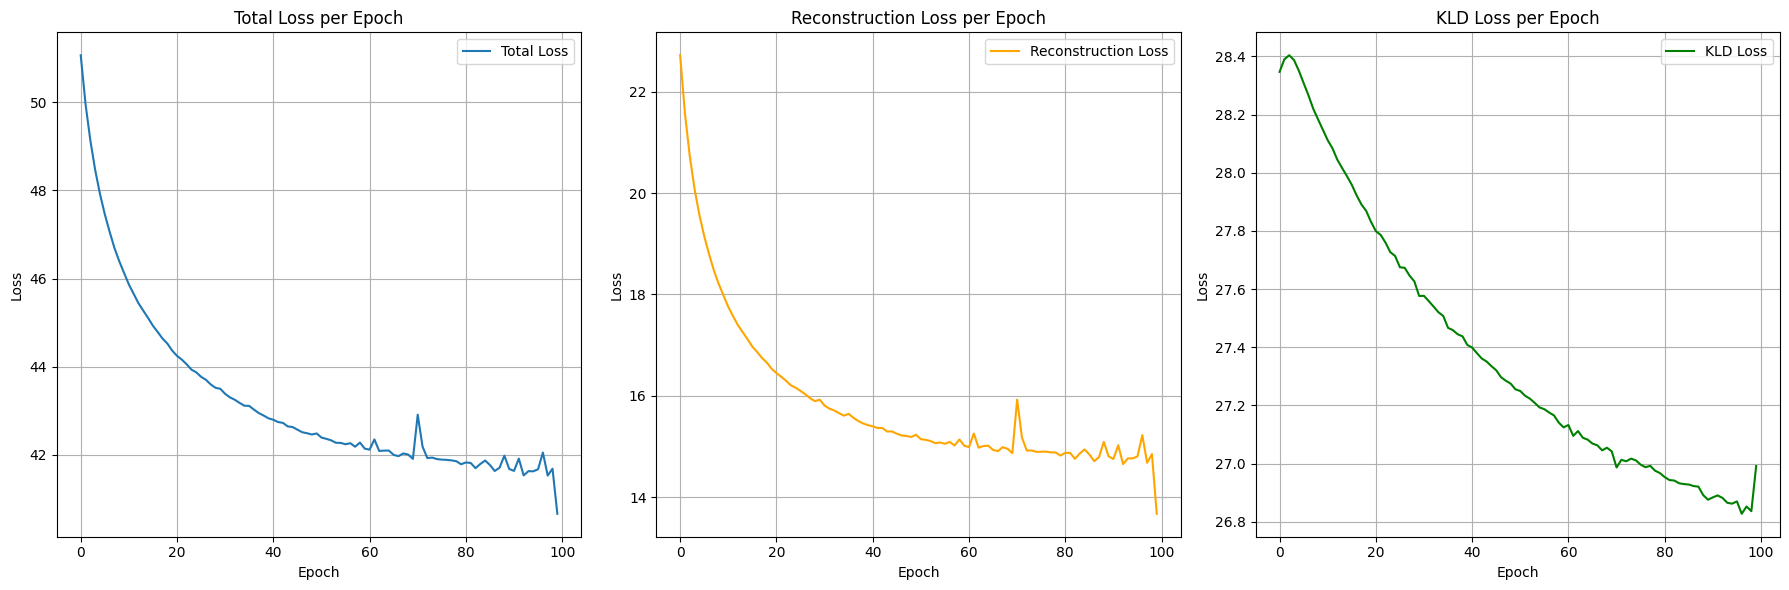

In [ ]:
plt.figure(figsize=(18, 6))

# Plot 1: Total Loss
plt.subplot(1, 3, 1)
plt.plot(history['total_loss'], label='Total Loss')
plt.title('Total Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Reconstruction Loss
plt.subplot(1, 3, 2)
plt.plot(history['recon_loss'], label='Reconstruction Loss', color='orange')
plt.title('Reconstruction Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 3: KL Divergence Loss
plt.subplot(1, 3, 3)
plt.plot(history['kld_loss'], label='KLD Loss', color='green')
plt.title('KLD Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Loading best model from /content/drive/My Drive/VAE_dsprites/vae_dsprites_best_model.pth...
Model loaded successfully.

--- Part 1: Reconstructing Images ---


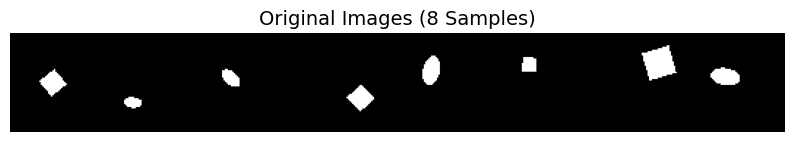

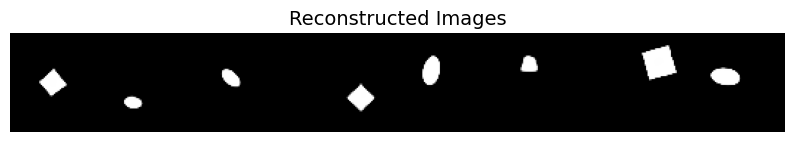


--- Part 2: Generating New Images ---


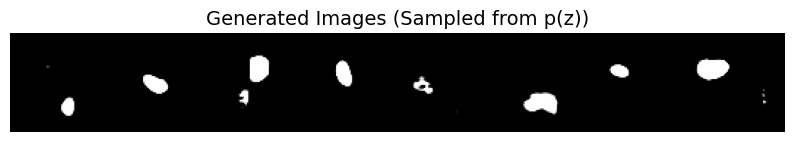

In [ ]:
# --- Helper Function to Plot Images ---
def show_images(images, title="", nrow=8):
    """Helper function to plot a grid of images"""

    # Detach from graph, move to CPU, make grid
    # We set normalize=False because our images are already 0-1
    grid = make_grid(images.detach().cpu(), nrow=nrow, padding=2, normalize=False)

    # Convert from (C, H, W) to (H, W, C) for matplotlib
    np_grid = grid.permute(1, 2, 0).numpy()

    plt.figure(figsize=(10, 2))
    # Use cmap='gray' for grayscale images
    plt.imshow(np_grid, cmap='gray')
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()

# --- 1. Load the Best Model ---
print(f"Loading best model from {BEST_MODEL_SAVE_PATH}...")

# Initialize a new model instance (structure must match the saved one)
model = VAE(h_dim=H_DIM).to(DEVICE)

# Load the saved weights (state dictionary)
model.load_state_dict(torch.load(BEST_MODEL_SAVE_PATH))

# *** CRITICAL ***
# Set the model to evaluation mode.
# This disables layers like Dropout or BatchNorm (if we had them).
model.eval()

print("Model loaded successfully.")


# --- 2. Reconstruct 8 Sample Images ---
print("\n--- Part 1: Reconstructing Images ---")

# Get a single batch of data from the DataLoader
try:
    original_images = next(iter(train_loader))
except NameError:
    print("Error: 'train_loader' is not defined.")
    print("Please make sure the data loading cell (Section 3) has been run.")
    raise

# Select 8 images from the batch and send them to the device
original_images_8 = original_images[:8].to(DEVICE)

# Pass the images through the *full* VAE (Encoder -> Reparameterize -> Decoder)
# We use torch.no_grad() to save memory and computation (no gradients needed)
with torch.no_grad():
    reconstructed_images, _, _ = model(original_images_8)

# Plot the originals
show_images(original_images_8, title="Original Images (8 Samples)")

# Plot the reconstructions
show_images(reconstructed_images, title="Reconstructed Images")


# --- 3. Generate 8 New Images (Sampling from Latent Space) ---
print("\n--- Part 2: Generating New Images ---")

# Create 8 random latent vectors (z)
# We sample from a Standard Normal distribution (mean=0, std=1)
# This is the "Prior" distribution (p(z)) of the VAE
z = torch.randn(8, H_DIM).to(DEVICE)

# Pass *only* through the decoder
with torch.no_grad():
    generated_images = model.decode(z)

# Plot the brand new, generated images
show_images(generated_images, title="Generated Images (Sampled from p(z))")

Q2-part1-subdivision6,7,8

In [6]:
# Section 3: Data Loading (Optimized - Replaces old Section 3)
print("Loading dsprites dataset (Robust Method - Saving Images AND Latents)...")

# --- Define Target File Paths ---
PROCESSED_IMAGES_FILENAME = 'dsprites_FINAL_uint8_N-C-H-W.npy'
PROCESSED_LATENTS_FILENAME = 'dsprites_FINAL_latents_classes.npy'

PROCESSED_IMAGES_PATH = os.path.join(BASE_PATH, PROCESSED_IMAGES_FILENAME)
PROCESSED_LATENTS_PATH = os.path.join(BASE_PATH, PROCESSED_LATENTS_FILENAME)

# --- Logic ---
# 1. Try to load processed files (FAST PATH)
if os.path.exists(PROCESSED_IMAGES_PATH) and os.path.exists(PROCESSED_LATENTS_PATH):
    print("Loading pre-processed images and latents from Drive (FAST PATH)...")
    all_images_np_uint8 = np.load(PROCESSED_IMAGES_PATH)
    all_latents_np = np.load(PROCESSED_LATENTS_PATH)

# 2. If they don't exist, create them (ONE-TIME SLOW PATH)
else:
    print("Pre-processed files not found. Running ONE-TIME data preparation...")

    ds_builder = tfds.builder('dsprites')
    ds_builder.download_and_prepare()
    ds = ds_builder.as_dataset(split='train')

    print("Converting dataset to NumPy arrays (uint8 images, int latents)...")
    numpy_ds = tfds.as_numpy(ds)

    all_images_list_uint8 = []
    all_latents_list = []

    for example in numpy_ds:
        all_images_list_uint8.append(example['image'])

        # Reconstruct latents array from individual keys (KeyError fix)
        latents = np.array([
            0, # Constant color factor
            example['label_shape'],
            example['label_scale'],
            example['label_orientation'],
            example['label_x_position'],
            example['label_y_position']
        ], dtype=np.int64)

        all_latents_list.append(latents)

    print("Stacking and transposing images...")
    all_images_np_uint8 = np.stack(all_images_list_uint8, axis=0)
    all_images_np_uint8 = np.transpose(all_images_np_uint8, (0, 3, 1, 2))

    print("Stacking latents...")
    all_latents_np = np.stack(all_latents_list, axis=0)

    del all_images_list_uint8, all_latents_list

    try:
        print(f"Saving processed images to: {PROCESSED_IMAGES_PATH}")
        np.save(PROCESSED_IMAGES_PATH, all_images_np_uint8)

        print(f"Saving processed latents to: {PROCESSED_LATENTS_PATH}")
        np.save(PROCESSED_LATENTS_PATH, all_latents_np)

        print("Successfully saved processed data.")
    except Exception as e:
        print(f"Error: Could not save processed data. {e}")

# --- Create PyTorch Dataset (for Training) ---
print(f"Image array ready: {all_images_np_uint8.shape}, dtype: {all_images_np_uint8.dtype}")
print(f"Latent array ready: {all_latents_np.shape}, dtype: {all_latents_np.dtype}")

# --- OPTIMIZATION 1 ---
# Dataset now returns uint8 tensors directly, no float conversion
class DspritesDataset(Dataset):
    def __init__(self, numpy_data_uint8):
        self.data = numpy_data_uint8

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 1. Get the uint8 image
        img_uint8 = self.data[idx]
        # 2. Convert to torch tensor *without* changing dtype
        img_uint8_tensor = torch.from_numpy(img_uint8)
        # 3. Return the 1-byte tensor
        return img_uint8_tensor

train_dataset = DspritesDataset(all_images_np_uint8)

# --- OPTIMIZATION 2 ---
# Increased num_workers to 8
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=8, # <-- Increased from 2
    pin_memory=True
)

print("Standard DataLoader (for training) created successfully (Optimized).")

Loading dsprites dataset (Robust Method - Saving Images AND Latents)...
Loading pre-processed images and latents from Drive (FAST PATH)...
Image array ready: (737280, 1, 64, 64), dtype: uint8
Latent array ready: (737280, 6), dtype: int64
Standard DataLoader (for training) created successfully (Optimized).


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



--- Starting Training for Beta = 3 ---
Epoch: 1/50 | Total Loss: 319.5799 | Recon Loss: 289.5396 | KLD Loss: 10.0134
Epoch: 2/50 | Total Loss: 107.8098 | Recon Loss: 55.5235 | KLD Loss: 17.4287
Epoch: 3/50 | Total Loss: 102.6722 | Recon Loss: 50.3146 | KLD Loss: 17.4525
Epoch: 4/50 | Total Loss: 99.8517 | Recon Loss: 47.6582 | KLD Loss: 17.3978
Epoch: 5/50 | Total Loss: 97.7378 | Recon Loss: 45.5833 | KLD Loss: 17.3848
Epoch: 6/50 | Total Loss: 95.9951 | Recon Loss: 43.8257 | KLD Loss: 17.3898
Epoch: 7/50 | Total Loss: 94.5310 | Recon Loss: 42.2749 | KLD Loss: 17.4187
Epoch: 8/50 | Total Loss: 93.2757 | Recon Loss: 40.8505 | KLD Loss: 17.4751
Epoch: 9/50 | Total Loss: 92.1862 | Recon Loss: 39.6891 | KLD Loss: 17.4990
Epoch: 10/50 | Total Loss: 91.3956 | Recon Loss: 38.8108 | KLD Loss: 17.5283
Epoch: 11/50 | Total Loss: 90.7723 | Recon Loss: 38.1387 | KLD Loss: 17.5445
Epoch: 12/50 | Total Loss: 90.1722 | Recon Loss: 37.5096 | KLD Loss: 17.5542
Epoch: 13/50 | Total Loss: 89.7020 | Reco

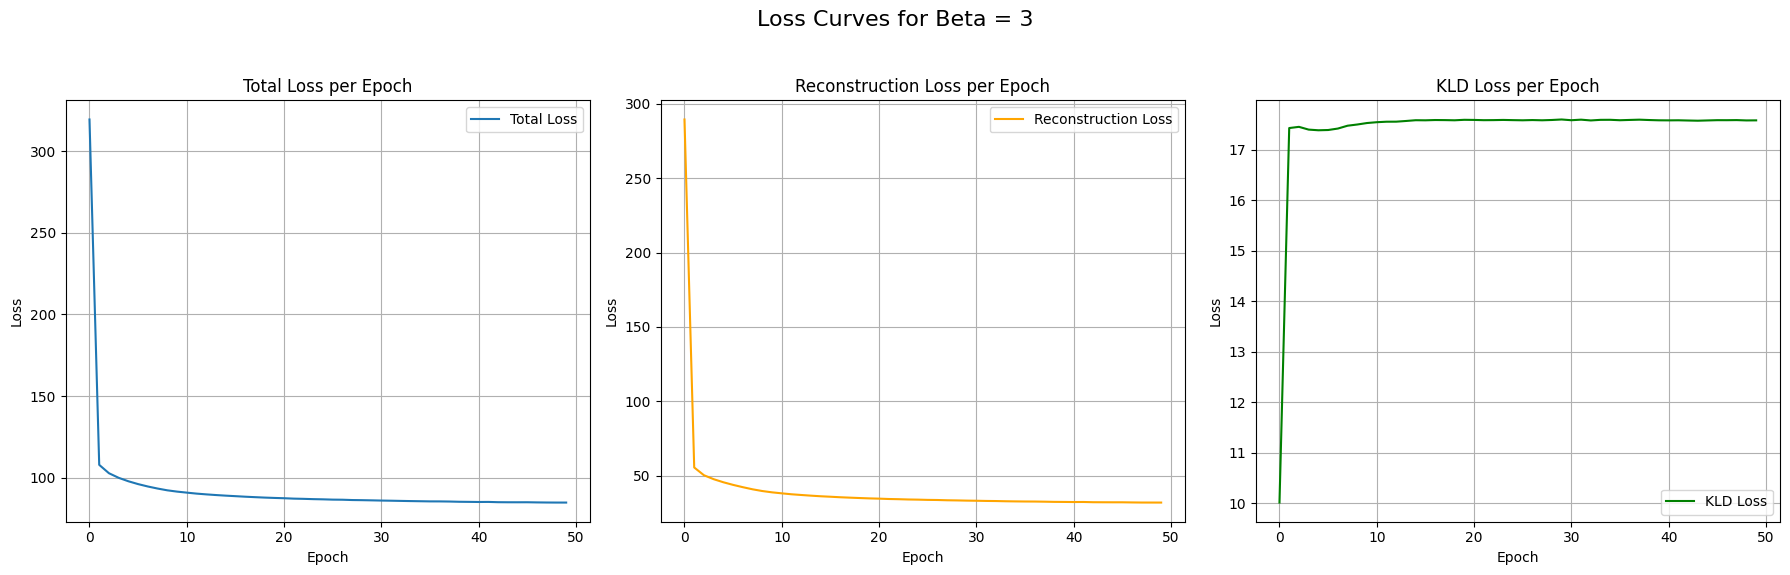

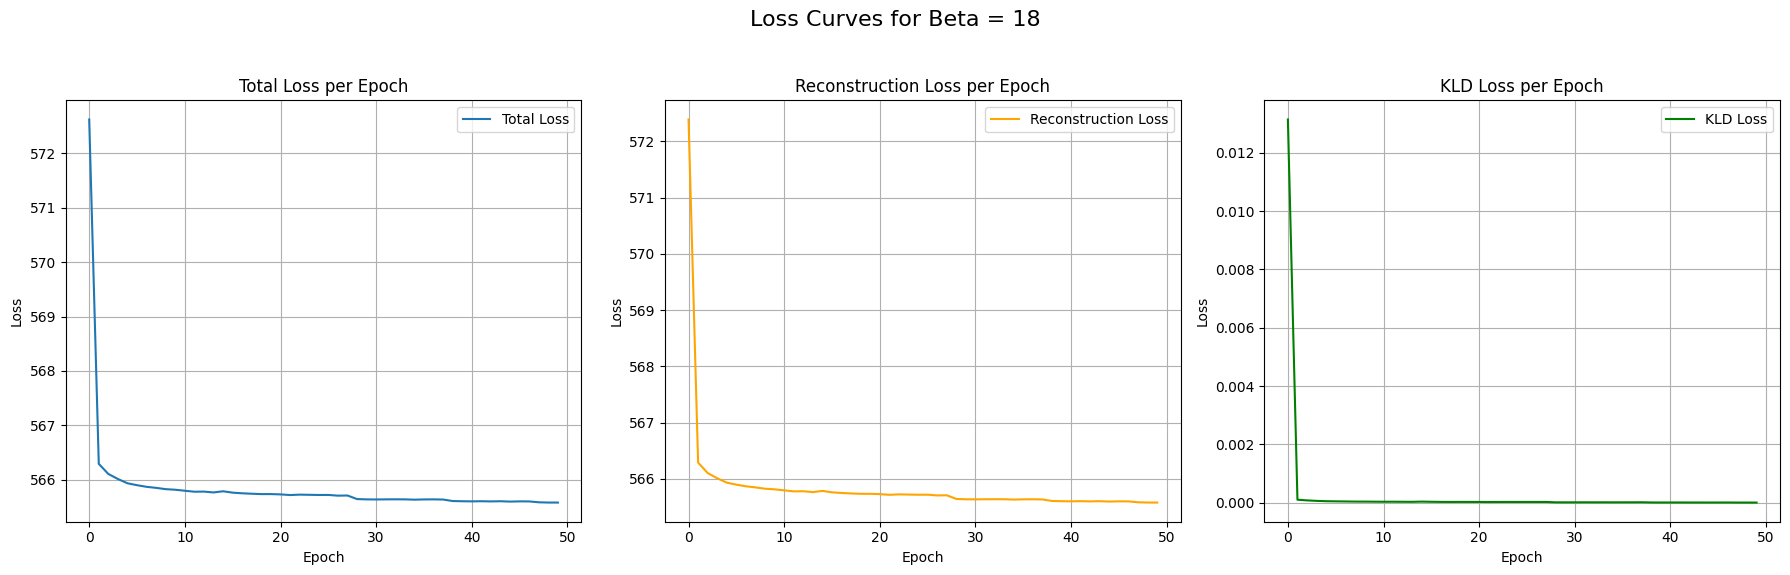

In [27]:
# Section 5: Beta-VAE Training Loop (Optimized - Replaces old Section 5)
MAX_EPOCHS = 50
# New loss function that accepts beta
def loss_function_beta(recon_x, x, mu, log_var, beta):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    return BCE + beta * KLD, BCE, KLD

# Helper function to plot loss curves
def plot_history(history, beta_value):
    plt.figure(figsize=(18, 6))
    plt.suptitle(f'Loss Curves for Beta = {beta_value}', fontsize=16)

    plt.subplot(1, 3, 1)
    plt.plot(history['total_loss'], label='Total Loss')
    plt.title('Total Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(history['recon_loss'], label='Reconstruction Loss', color='orange')
    plt.title('Reconstruction Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(history['kld_loss'], label='KLD Loss', color='green')
    plt.title('KLD Loss per Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Comprehensive training function
def train_beta_vae(beta_value):
    print(f"\n--- Starting Training for Beta = {beta_value} ---")

    model = VAE(h_dim=H_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=INITIAL_LR)
    scheduler = lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=SCHEDULER_FACTOR, patience=SCHEDULER_PATIENCE
    )
    model_save_path = os.path.join(BASE_PATH, f"vae_dsprites_beta_{beta_value}.pth")

    history = {'total_loss': [], 'recon_loss': [], 'kld_loss': []}
    best_loss = float('inf')
    epochs_no_improve = 0

    model.train()
    start_time = time.time()

    for epoch in range(1, MAX_EPOCHS + 1):
        epoch_total_loss, epoch_recon_loss, epoch_kld_loss = 0, 0, 0

        for data in train_loader:

            # --- OPTIMIZATION 3 ---
            # 'data' is uint8 here
            data = data.to(DEVICE) # 1. Move uint8 tensor to GPU (fast)
            data = data.float()    # 2. Convert to float32 ON THE GPU (super fast)
            # --- END OPTIMIZATION ---

            recon_batch, mu, log_var = model(data)

            total_loss, recon_loss, kld_loss = loss_function_beta(
                recon_batch, data, mu, log_var, beta=beta_value
            )

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            epoch_total_loss += total_loss.item()
            epoch_recon_loss += recon_loss.item()
            epoch_kld_loss += kld_loss.item()

        avg_total_loss = epoch_total_loss / len(train_loader.dataset)
        avg_recon_loss = epoch_recon_loss / len(train_loader.dataset)
        avg_kld_loss = epoch_kld_loss / len(train_loader.dataset)

        history['total_loss'].append(avg_total_loss)
        history['recon_loss'].append(avg_recon_loss)
        history['kld_loss'].append(avg_kld_loss)

        print(f'Epoch: {epoch}/{MAX_EPOCHS} | Total Loss: {avg_total_loss:.4f} | '
              f'Recon Loss: {avg_recon_loss:.4f} | KLD Loss: {avg_kld_loss:.4f}')

        scheduler.step(avg_total_loss)

        if avg_total_loss < best_loss:
            best_loss = avg_total_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_save_path)
        else:
            epochs_no_improve += 1
            print(f'\tEarlyStopping counter: {epochs_no_improve}/{EARLY_STOP_PATIENCE}')

        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping triggered after {epoch} epochs.')
            break

    total_time = time.time() - start_time
    print(f"--- Training Finished for Beta = {beta_value} in {total_time:.2f}s ---")
    print(f"Best model saved to {model_save_path}")

    return history, model_save_path

# --- Run Training for Beta=3 and Beta=18 ---
# (This should now run noticeably faster)

history_beta_3, path_beta_3 = train_beta_vae(beta_value=3)
history_beta_18, path_beta_18 = train_beta_vae(beta_value=18)

print("\n--- All models trained. Plotting losses... ---")

plot_history(history_beta_3, beta_value=3)
plot_history(history_beta_18, beta_value=18)

In [10]:
path_beta_3 = '/content/drive/My Drive/VAE_dsprites/vae_dsprites_beta_3.pth'
path_beta_18 = '/content/drive/My Drive/VAE_dsprites/vae_dsprites_beta_18.pth'


--- Evaluating Model for Beta = 1 ---
Loading model from /content/drive/My Drive/VAE_dsprites/vae_dsprites_best_model.pth...


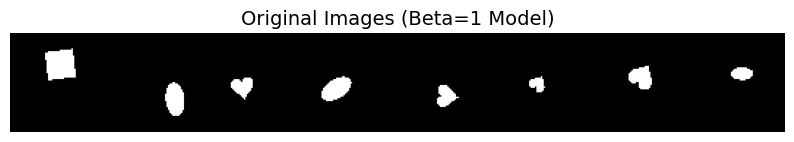

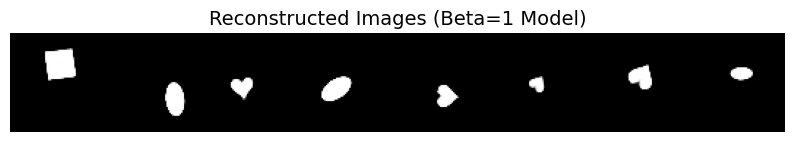

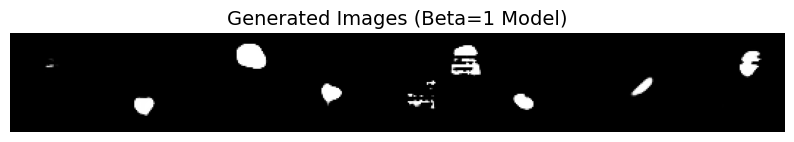


--- Evaluating Model for Beta = 3 ---
Loading model from /content/drive/My Drive/VAE_dsprites/vae_dsprites_beta_3.pth...


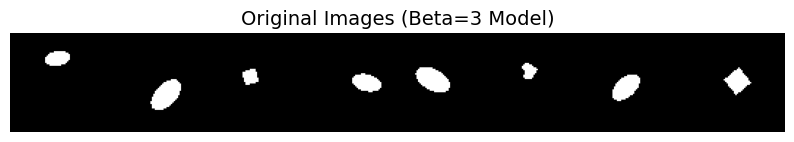

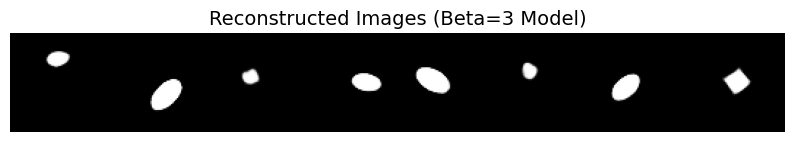

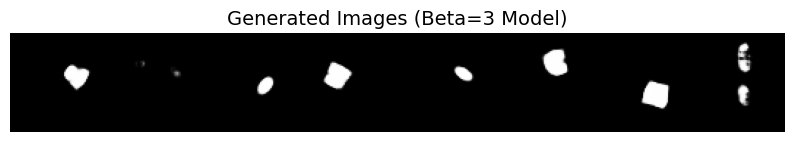


--- Evaluating Model for Beta = 18 ---
Loading model from /content/drive/My Drive/VAE_dsprites/vae_dsprites_beta_18.pth...


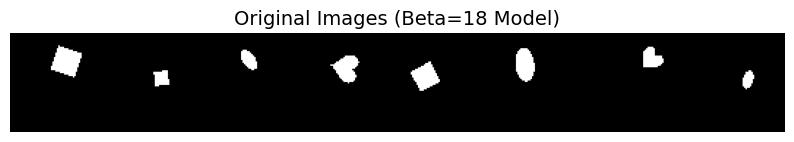

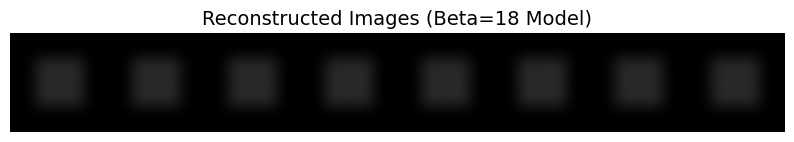

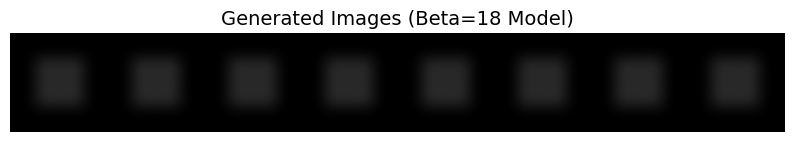

In [28]:
# Section 7 (Fixed: Show Original Images): Evaluate All Three Models

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

# Helper function to plot images (No changes needed)
def show_images(images, title="", nrow=8):
    grid = make_grid(images.detach().cpu(), nrow=nrow, padding=2, normalize=False)
    np_grid = grid.permute(1, 2, 0).numpy()
    plt.figure(figsize=(10, 2))
    plt.imshow(np_grid, cmap='gray')
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.show()

# Comprehensive evaluation function
def evaluate_and_show(model_path, beta_value):
    print(f"\n--- Evaluating Model for Beta = {beta_value} ---")
    print(f"Loading model from {model_path}...")

    model = VAE(h_dim=H_DIM).to(DEVICE)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # --- 1. Reconstruction ---
    # train_loader now returns uint8 tensors
    original_images_8 = next(iter(train_loader))[:8].to(DEVICE)

    with torch.no_grad():
        # Convert to float *before* model call (fixes runtime error)
        reconstructed_images, _, _ = model(original_images_8.float())

    # --- FIX IS HERE ---
    # We must also convert to float *before plotting*
    # to show original images in [0.0, 1.0] range
    show_images(original_images_8.float(), title=f"Original Images (Beta={beta_value} Model)")
    # --- END FIX ---

    show_images(reconstructed_images, title=f"Reconstructed Images (Beta={beta_value} Model)")

    # --- 2. Generation ---
    # (This part was already correct)
    z = torch.randn(8, H_DIM).to(DEVICE)
    with torch.no_grad():
        generated_images = model.decode(z)

    show_images(generated_images, title=f"Generated Images (Beta={beta_value} Model)")

# --- Run Evaluation ---
try:
    evaluate_and_show(BEST_MODEL_SAVE_PATH, beta_value=1)
except (FileNotFoundError, NameError):
    print("Warning: Could not find original Beta=1 model. Skipping evaluation.")

evaluate_and_show(path_beta_3, beta_value=3)
evaluate_and_show(path_beta_18, beta_value=18)

In [11]:
# Section 8 (Fixed Import): MIG (Mutual Information Gap) Calculation

import numpy as np
# --- FIX IS HERE ---
# Import from sklearn.feature_selection instead of sklearn.metrics
from sklearn.feature_selection import mutual_info_classif
# --- END FIX ---

print("\n--- Calculating MIG (Mutual Information Gap) ---")
print("This may take a few minutes...")

# --- 1. Create a new Dataset and DataLoader for MIG ---
# (This dataset returns both images and ground-truth latents)

class MIGDataset(Dataset):
    def __init__(self, images_path, latents_path):
        print("Loading MIG dataset arrays from disk...")
        self.images = np.load(images_path)
        self.latents = np.load(latents_path)
        print("MIG dataset loaded.")

    def __len__(self):
        return 50000 # Use a robust subset

    def __getitem__(self, idx):
        # 1. Get uint8 image
        img_uint8 = self.images[idx]
        # 2. Return uint8 tensor (no float conversion)
        img_uint8_tensor = torch.from_numpy(img_uint8)

        latent_classes = self.latents[idx]

        return img_uint8_tensor, latent_classes

mig_dataset = MIGDataset(PROCESSED_IMAGES_PATH, PROCESSED_LATENTS_PATH)

# IMPORTANT: shuffle=False is critical for MIG
mig_loader = DataLoader(
    mig_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2, # Set to 2 (based on your warning)
    pin_memory=True
)

# --- 2. Helper function to get all predictions ---
def get_all_latents(model, loader):
    model.eval()
    all_pred_mus = []
    all_true_latents = []

    print(f"Running inference to get {len(loader.dataset)} latent representations...")
    with torch.no_grad():
        for images, latents in loader:
            # images is uint8
            images = images.to(DEVICE)

            # Convert to float32 ON THE GPU before model call
            images = images.float()

            mu, _ = model.encode(images)

            all_pred_mus.append(mu.cpu())
            all_true_latents.append(latents)

    all_pred_mus = torch.cat(all_pred_mus, dim=0).numpy()
    all_true_latents = torch.cat(all_true_latents, dim=0).numpy()

    return all_pred_mus, all_true_latents

# --- 3. MIG Calculation Function ---
def calculate_mig(pred_mus, true_latents):
    num_factors = true_latents.shape[1]
    num_latents = pred_mus.shape[1]
    mi_matrix = np.zeros((num_factors, num_latents))
    factor_names = ["Color (Const)", "Shape", "Scale", "Orientation", "PosX", "PosY"]

    for k in range(1, num_factors): # Skip factor 0
        true_factor = true_latents[:, k]
        mi_scores = mutual_info_classif(pred_mus, true_factor, discrete_features=False)
        mi_matrix[k, :] = mi_scores

    gaps = []
    print("\n--- Mutual Information Matrix (Ground-Truth Factors vs. Predicted Latents) ---")
    print("Rows: True Factors (Shape, Scale, Orient, PosX, PosY)")
    print("Cols: Predicted Latent Dims (0-9)")
    print(np.round(mi_matrix[1:], 3))

    for k in range(1, num_factors):
        mi_scores_for_factor = mi_matrix[k, :]
        mi_scores_for_factor.sort()

        mi_max = mi_scores_for_factor[-1]
        mi_second_max = mi_scores_for_factor[-2]
        gap = mi_max - mi_second_max

        print(f"Factor: {factor_names[k]:<12} | Max MI: {mi_max:.3f}, 2nd MI: {mi_second_max:.3f} | Gap: {gap:.3f}")
        gaps.append(gap)

    mig_score = np.mean(gaps)
    return mig_score

# --- 4. Run MIG Calculation for all models ---
try:
    model_vae_1 = VAE(h_dim=H_DIM).to(DEVICE)
    model_vae_1.load_state_dict(torch.load(BEST_MODEL_SAVE_PATH))
    pred_mus_1, true_latents_1 = get_all_latents(model_vae_1, mig_loader)
    print("\n--- Calculating MIG for Beta = 1 (Original VAE) ---")
    mig_1 = calculate_mig(pred_mus_1, true_latents_1)
except (FileNotFoundError, NameError):
    print("\nWarning: Could not load Beta=1 model. Skipping MIG calculation for it.")
    mig_1 = 0.0

model_vae_3 = VAE(h_dim=H_DIM).to(DEVICE)
model_vae_3.load_state_dict(torch.load(path_beta_3))
pred_mus_3, true_latents_3 = get_all_latents(model_vae_3, mig_loader)
print("\n--- Calculating MIG for Beta = 3 ---")
mig_3 = calculate_mig(pred_mus_3, true_latents_3)

model_vae_18 = VAE(h_dim=H_DIM).to(DEVICE)
model_vae_18.load_state_dict(torch.load(path_beta_18))
pred_mus_18, true_latents_18 = get_all_latents(model_vae_18, mig_loader)
print("\n--- Calculating MIG for Beta = 18 ---")
mig_18 = calculate_mig(pred_mus_18, true_latents_18)

# --- Final Report ---
print("\n" + "="*30)
print("--- FINAL MIG SCORES ---")
print(f"VAE (Beta=1):     MIG = {mig_1:.4f}")
print(f"Beta-VAE (B=3):   MIG = {mig_3:.4f}")
print(f"Beta-VAE (B=18):  MIG = {mig_18:.4f}")
print("\n(Higher MIG score is better and indicates better disentanglement)")
print("="*30)


--- Calculating MIG (Mutual Information Gap) ---
This may take a few minutes...
Loading MIG dataset arrays from disk...
MIG dataset loaded.
Running inference to get 50000 latent representations...

--- Calculating MIG for Beta = 1 (Original VAE) ---

--- Mutual Information Matrix (Ground-Truth Factors vs. Predicted Latents) ---
Rows: True Factors (Shape, Scale, Orient, PosX, PosY)
Cols: Predicted Latent Dims (0-9)
[[0.015 0.087 0.014 0.028 0.035 0.017 0.016 0.024 0.021 0.041]
 [0.045 0.021 0.021 0.061 0.027 0.025 0.015 0.071 0.13  0.161]
 [0.025 0.031 0.029 0.033 0.014 0.025 0.047 0.018 0.002 0.018]
 [0.071 0.037 0.041 0.243 0.011 0.144 0.238 0.231 0.276 0.104]
 [0.298 0.027 0.067 0.136 0.006 0.161 0.136 0.194 0.25  0.263]]
Factor: Shape        | Max MI: 0.087, 2nd MI: 0.041 | Gap: 0.045
Factor: Scale        | Max MI: 0.161, 2nd MI: 0.130 | Gap: 0.031
Factor: Orientation  | Max MI: 0.047, 2nd MI: 0.033 | Gap: 0.013
Factor: PosX         | Max MI: 0.276, 2nd MI: 0.243 | Gap: 0.033
Facto

--- Section 9: PCA Visualization for ALL Models ---

--- Analyzing Model: VAE (Beta=1) ---
--- Path: /content/drive/My Drive/VAE_dsprites/vae_dsprites_best_model.pth ---
Successfully loaded model: VAE (Beta=1)
Running inference to get 50000 latent representations...
Extracted 50000 samples of 10-dim latents.
Running PCA to reduce 10-dim space to 2-dim...
PCA complete. Total variance explained by 2 components: 25.35%
Generating PCA scatter plots...


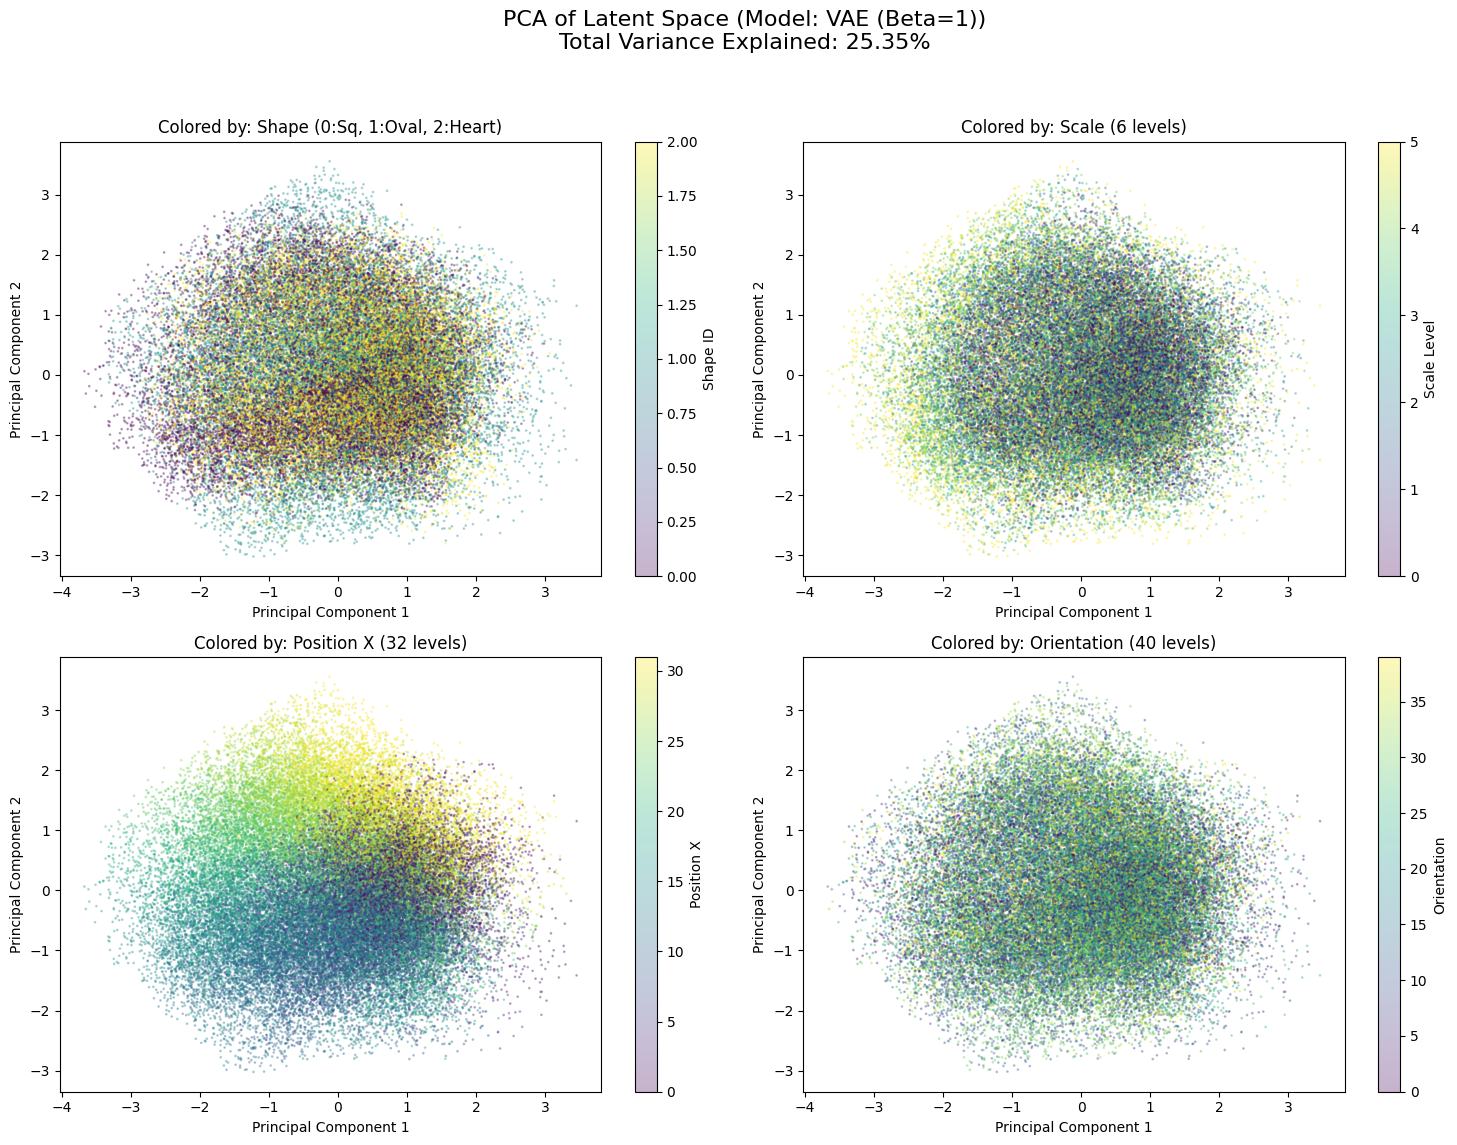


--- Analyzing Model: Beta-VAE (B=3) ---
--- Path: /content/drive/My Drive/VAE_dsprites/vae_dsprites_beta_3.pth ---
Successfully loaded model: Beta-VAE (B=3)
Running inference to get 50000 latent representations...
Extracted 50000 samples of 10-dim latents.
Running PCA to reduce 10-dim space to 2-dim...
PCA complete. Total variance explained by 2 components: 27.14%
Generating PCA scatter plots...


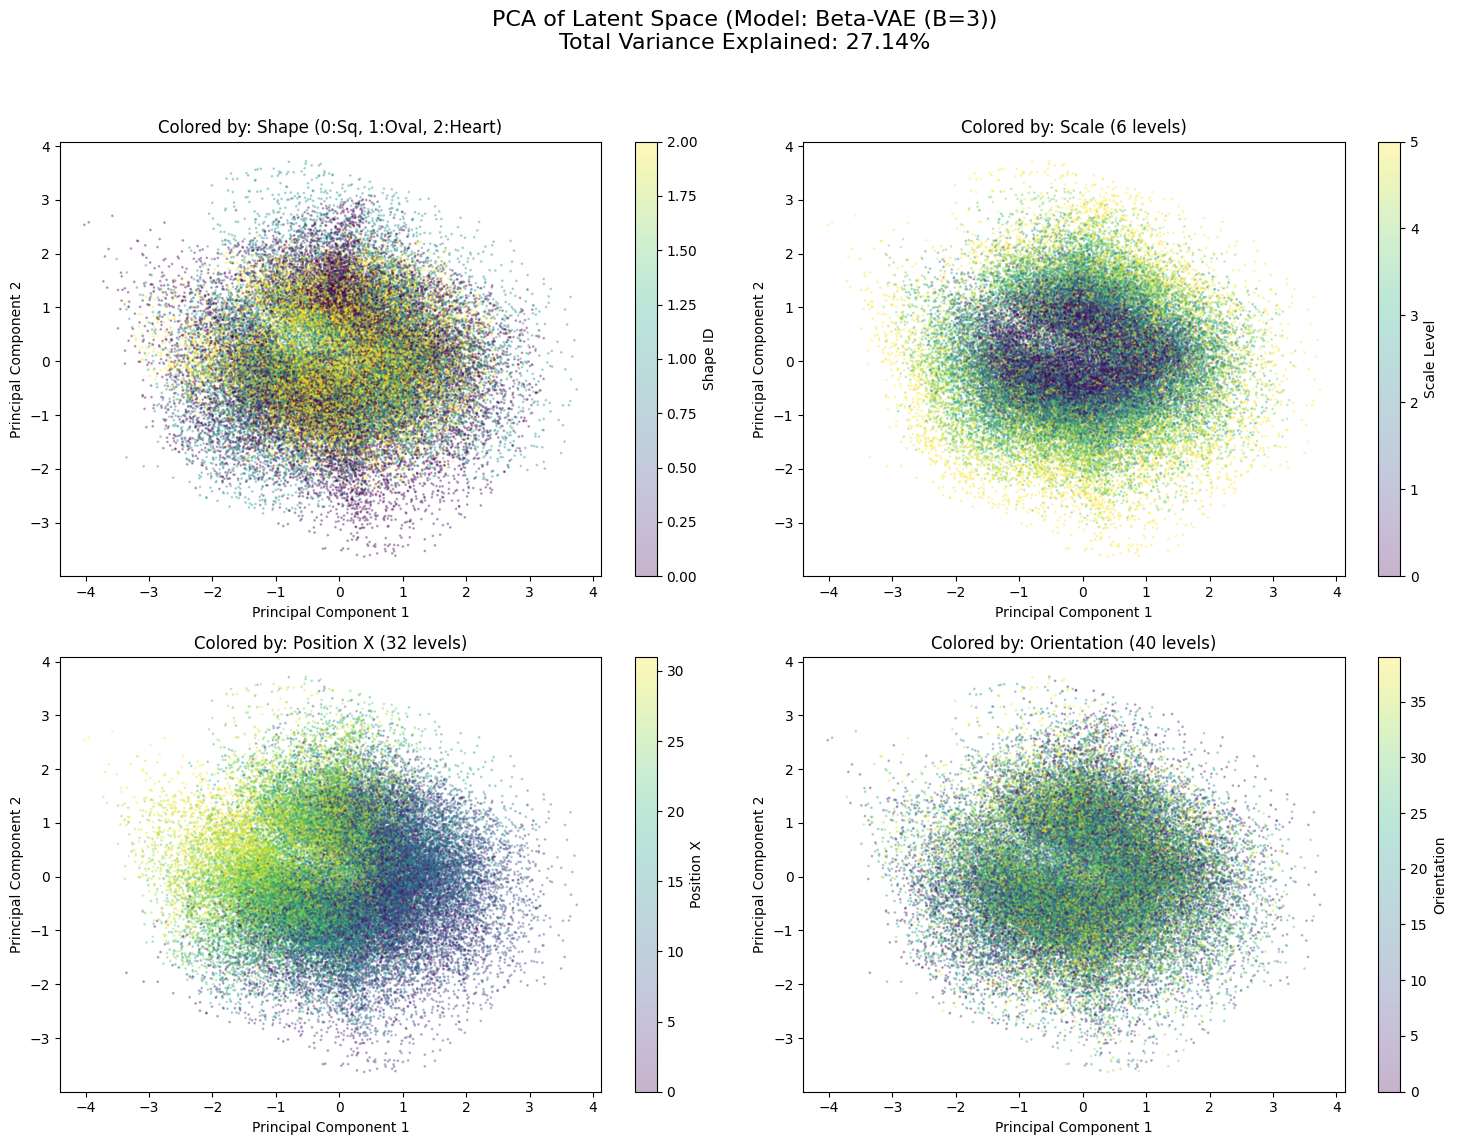


--- Analyzing Model: Beta-VAE (B=18) ---
--- Path: /content/drive/My Drive/VAE_dsprites/vae_dsprites_beta_18.pth ---
Successfully loaded model: Beta-VAE (B=18)
Running inference to get 50000 latent representations...
Extracted 50000 samples of 10-dim latents.
Running PCA to reduce 10-dim space to 2-dim...
PCA complete. Total variance explained by 2 components: 99.78%
Generating PCA scatter plots...


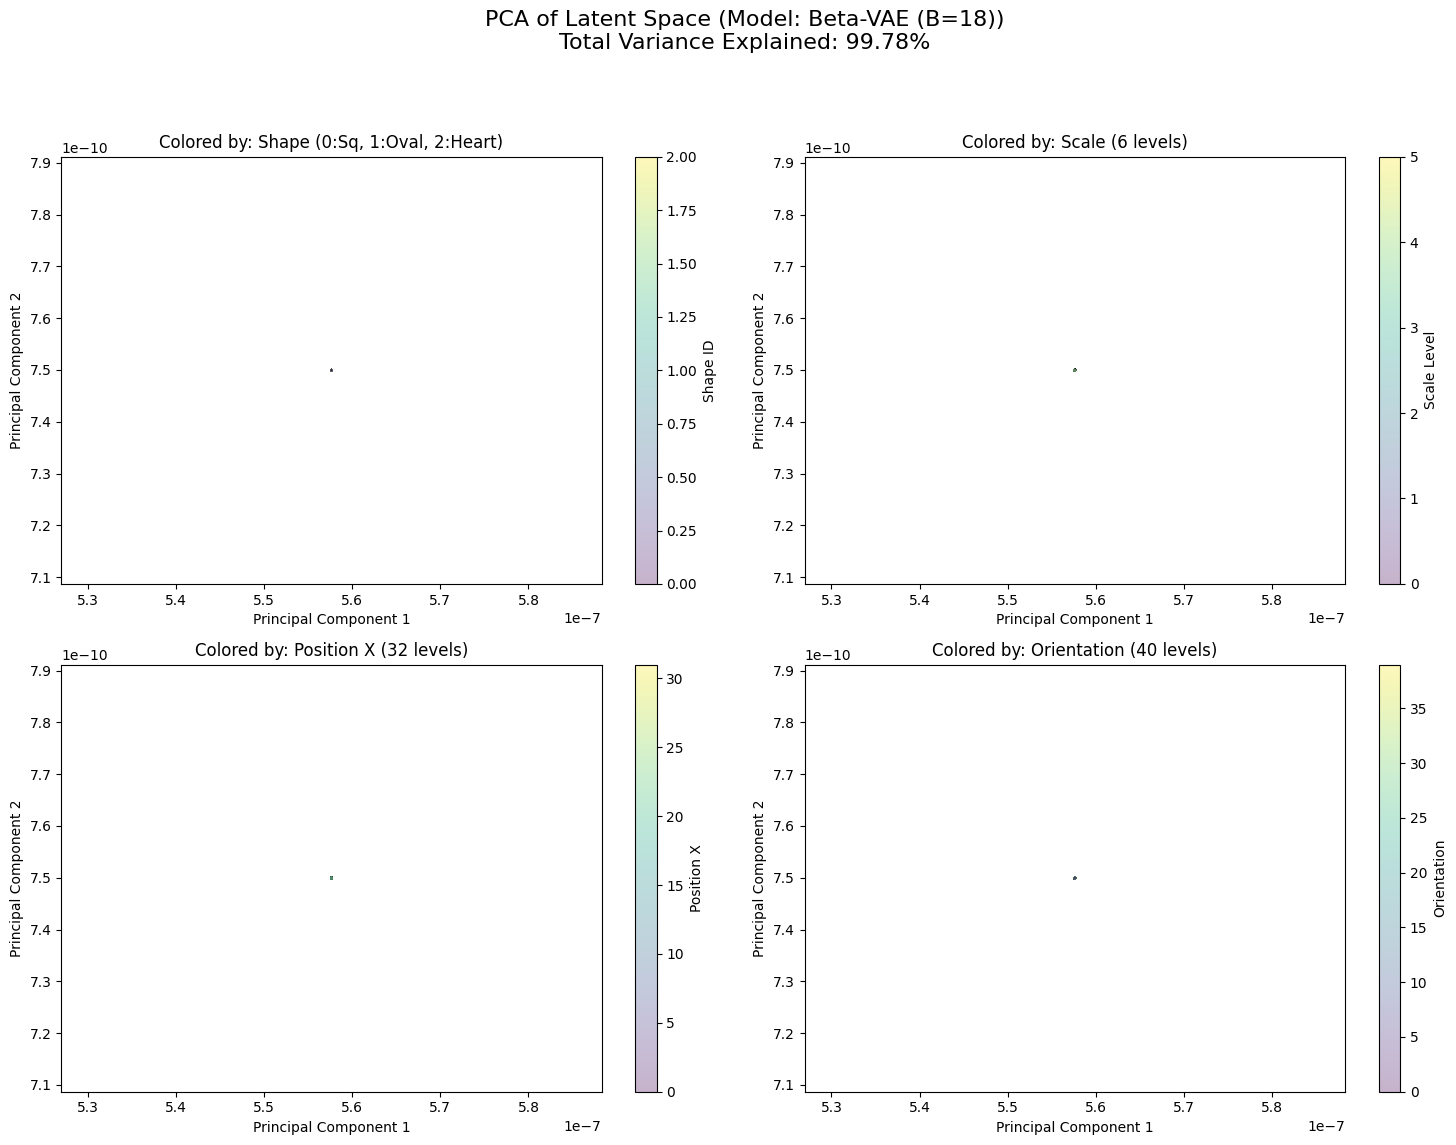


--- PCA analysis complete for all models. ---


In [13]:
# Section 9: PCA Visualization (Looping over all models)

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

print("--- Section 9: PCA Visualization for ALL Models ---")

# --- 1. Define all models to analyze ---
# We create a list of dictionaries to loop over
models_to_analyze = [
    {
        "name": "VAE (Beta=1)",
        "path": BEST_MODEL_SAVE_PATH
    },
    {
        "name": "Beta-VAE (B=3)",
        "path": path_beta_3
    },
    {
        "name": "Beta-VAE (B=18)",
        "path": path_beta_18
    }
]

factor_names = {
    1: "Shape (0:Sq, 1:Oval, 2:Heart)",
    2: "Scale (6 levels)",
    3: "Orientation (40 levels)",
    4: "Position X (32 levels)",
    5: "Position Y (32 levels)"
}

# --- 2. Loop through each model ---
for model_info in models_to_analyze:
    model_name = model_info['name']
    model_path = model_info['path']

    print(f"\n" + "="*30)
    print(f"--- Analyzing Model: {model_name} ---")
    print(f"--- Path: {model_path} ---")
    print("="*30)

    # --- 2a. Load Model ---
    try:
        model_pca = VAE(h_dim=H_DIM).to(DEVICE)
        model_pca.load_state_dict(torch.load(model_path))
        model_pca.eval()
        print(f"Successfully loaded model: {model_name}")
    except Exception as e:
        print(f"Error loading model: {e}. Skipping this model.")
        continue # Skip to the next model in the loop

    # --- 2b. Get Latent Representations ---
    try:
        pred_mus, true_latents = get_all_latents(model_pca, mig_loader)
        print(f"Extracted {pred_mus.shape[0]} samples of {pred_mus.shape[1]}-dim latents.")
    except NameError:
        print("Error: 'get_all_latents' or 'mig_loader' not found. Stopping.")
        break # Exit the loop if helpers aren't defined
    except Exception as e:
        print(f"Error during inference: {e}. Skipping this model.")
        continue

    # --- 2c. Apply PCA ---
    print("Running PCA to reduce 10-dim space to 2-dim...")
    pca = PCA(n_components=2)
    latents_2d = pca.fit_transform(pred_mus)

    variance_explained = np.sum(pca.explained_variance_ratio_) * 100
    print(f"PCA complete. Total variance explained by 2 components: {variance_explained:.2f}%")


    # --- 2d. Plot Scatter Plot (Colored by Ground-Truth Factors) ---
    print("Generating PCA scatter plots...")
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'PCA of Latent Space (Model: {model_name})\n'
                 f'Total Variance Explained: {variance_explained:.2f}%',
                 fontsize=16)

    # Plot 1: Colored by Shape (Index 1)
    ax = axes[0, 0]
    factor_data = true_latents[:, 1]
    scatter = ax.scatter(latents_2d[:, 0], latents_2d[:, 1], c=factor_data,
                         cmap='viridis', s=1, alpha=0.3)
    ax.set_title(f'Colored by: {factor_names[1]}')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    fig.colorbar(scatter, ax=ax, label='Shape ID')

    # Plot 2: Colored by Scale (Index 2)
    ax = axes[0, 1]
    factor_data = true_latents[:, 2]
    scatter = ax.scatter(latents_2d[:, 0], latents_2d[:, 1], c=factor_data,
                         cmap='viridis', s=1, alpha=0.3)
    ax.set_title(f'Colored by: {factor_names[2]}')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    fig.colorbar(scatter, ax=ax, label='Scale Level')

    # Plot 3: Colored by Position X (Index 4)
    ax = axes[1, 0]
    factor_data = true_latents[:, 4]
    scatter = ax.scatter(latents_2d[:, 0], latents_2d[:, 1], c=factor_data,
                         cmap='viridis', s=1, alpha=0.3)
    ax.set_title(f'Colored by: {factor_names[4]}')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2') # Typo fixed here
    fig.colorbar(scatter, ax=ax, label='Position X')

    # Plot 4: Colored by Orientation (Index 3)
    ax = axes[1, 1]
    factor_data = true_latents[:, 3]
    scatter = ax.scatter(latents_2d[:, 0], latents_2d[:, 1], c=factor_data,
                         cmap='viridis', s=1, alpha=0.3)
    ax.set_title(f'Colored by: {factor_names[3]}')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    fig.colorbar(scatter, ax=ax, label='Orientation')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("\n--- PCA analysis complete for all models. ---")